# Projeto de Redes Neurais Artificiais - Detecção de Páginas Web de Phishing Baseada em Perceptron Multicamadas (MLP)

Instalação de Dependências

In [7]:
pip install ucimlrepo tensorflow scikit-learn matplotlib seaborn shap

Importações

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import shap

Carregamento do Dataset

In [9]:
phishing_websites = fetch_ucirepo(id=327)

X = phishing_websites.data.features
y = phishing_websites.data.targets

y_single = y.iloc[:, 0]
y_binary = y_single.apply(lambda x: 1 if x == -1 else 0)

print("Formato das features (X):", X.shape)
print("Distribuição das classes:\n", y_binary.value_counts())

Formato das features (X): (11055, 30)
Distribuição das classes:
 result
0    6157
1    4898
Name: count, dtype: int64


Divisão e Padronização dos Dados

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Construção e Compilação da Rede Neural

In [11]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Treinamento da Rede Neural

In [12]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8643 - loss: 0.3168 - val_accuracy: 0.9389 - val_loss: 0.1737
Epoch 2/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9276 - loss: 0.1803 - val_accuracy: 0.9412 - val_loss: 0.1563
Epoch 3/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9345 - loss: 0.1645 - val_accuracy: 0.9439 - val_loss: 0.1470
Epoch 4/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9395 - loss: 0.1492 - val_accuracy: 0.9462 - val_loss: 0.1377
Epoch 5/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9412 - loss: 0.1417 - val_accuracy: 0.9493 - val_loss: 0.1318
Epoch 6/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9438 - loss: 0.1345 - val_accuracy: 0.9521 - val_loss: 0.1239
Epoch 7/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9480 - loss: 0.1267 - val_accuracy: 0.9534 - val_loss: 0.1225
Epoch 8/30
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9474 - loss: 0.1214 - val_accuracy: 0.

Gráfico de Perda

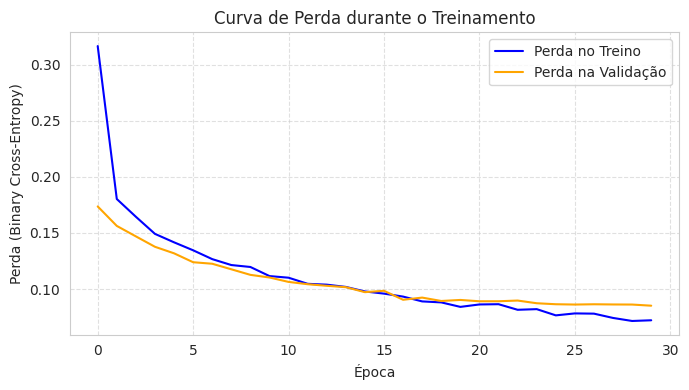

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='Perda no Treino', color='blue')
plt.plot(history.history['val_loss'], label='Perda na Validação', color='orange')
plt.xlabel('Época')
plt.ylabel('Perda (Binary Cross-Entropy)')
plt.legend()
plt.title('Curva de Perda durante o Treinamento')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=300)
plt.show()

Gráfico de Acurácia

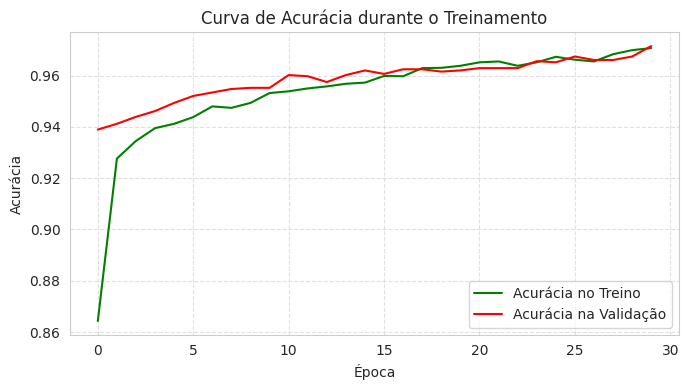

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['accuracy'], label='Acurácia no Treino', color='green')
plt.plot(history.history['val_accuracy'], label='Acurácia na Validação', color='red')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.title('Curva de Acurácia durante o Treinamento')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('accuracy_curve.png', dpi=300)
plt.show()

Predições e Matriz de Confusão

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


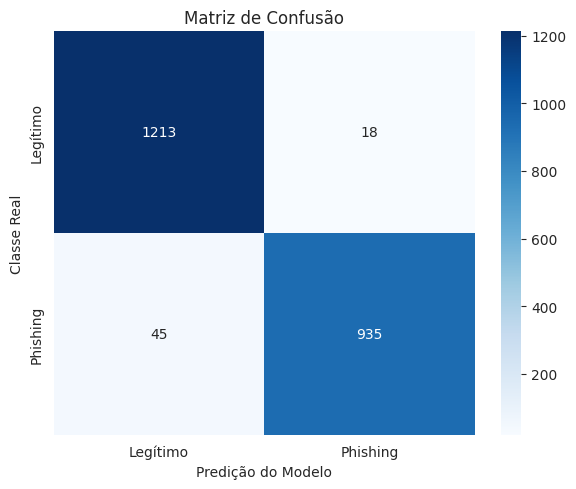


Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1231
           1       0.98      0.95      0.97       980

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



In [15]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítimo', 'Phishing'],
            yticklabels=['Legítimo', 'Phishing'])
plt.xlabel('Predição do Modelo')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

SHAP

PermutationExplainer explainer: 201it [00:29,  3.83it/s]                         
/tmp/ipykernel_673/2647876702.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled[:200], feature_names=X.columns, show=False)


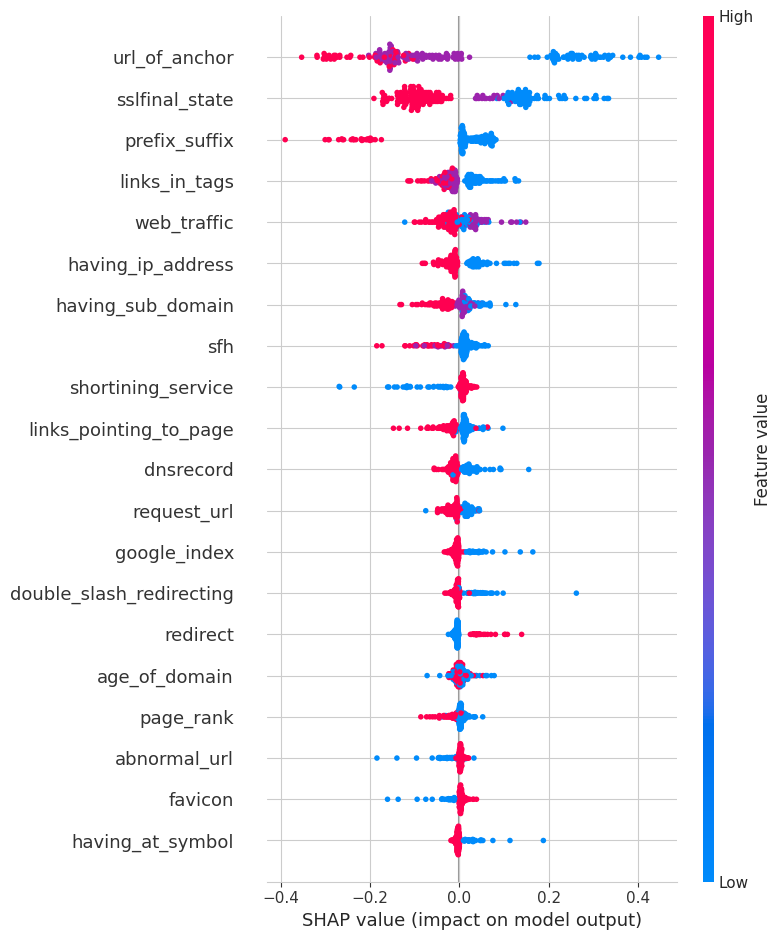

In [16]:
explainer = shap.Explainer(model, X_train_scaled[:100])
shap_values = explainer(X_test_scaled[:200])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled[:200], feature_names=X.columns, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300)
plt.show()